In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error,mean_squared_error
import tensorflow as tf
from keras import Model
from keras.layers import Input, Dense, Dropout, LSTM
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [ ]:
df = pd.read_csv(r'Gold Price (2013-2023).csv')
df.drop(['Vol.', 'Change %'], axis=1, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(by='Date', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
NumCols = df.columns.drop(['Date'])
df[NumCols] = df[NumCols].replace({',': ''}, regex=True)
df[NumCols] = df[NumCols].astype('float64')

In [ ]:
fig = px.line(y=df.Price, x=df.Date)
fig.update_traces(line_color='black')
fig.update_layout(xaxis_title="Date",
                  yaxis_title="Scaled Price",
                  title={'text': "Gold Price History Data", 'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'},
                  plot_bgcolor='rgba(255,223,0,0.8)')

In [ ]:
test_size = df[df.Date.dt.year.isin([2022, 2023])].shape[0]

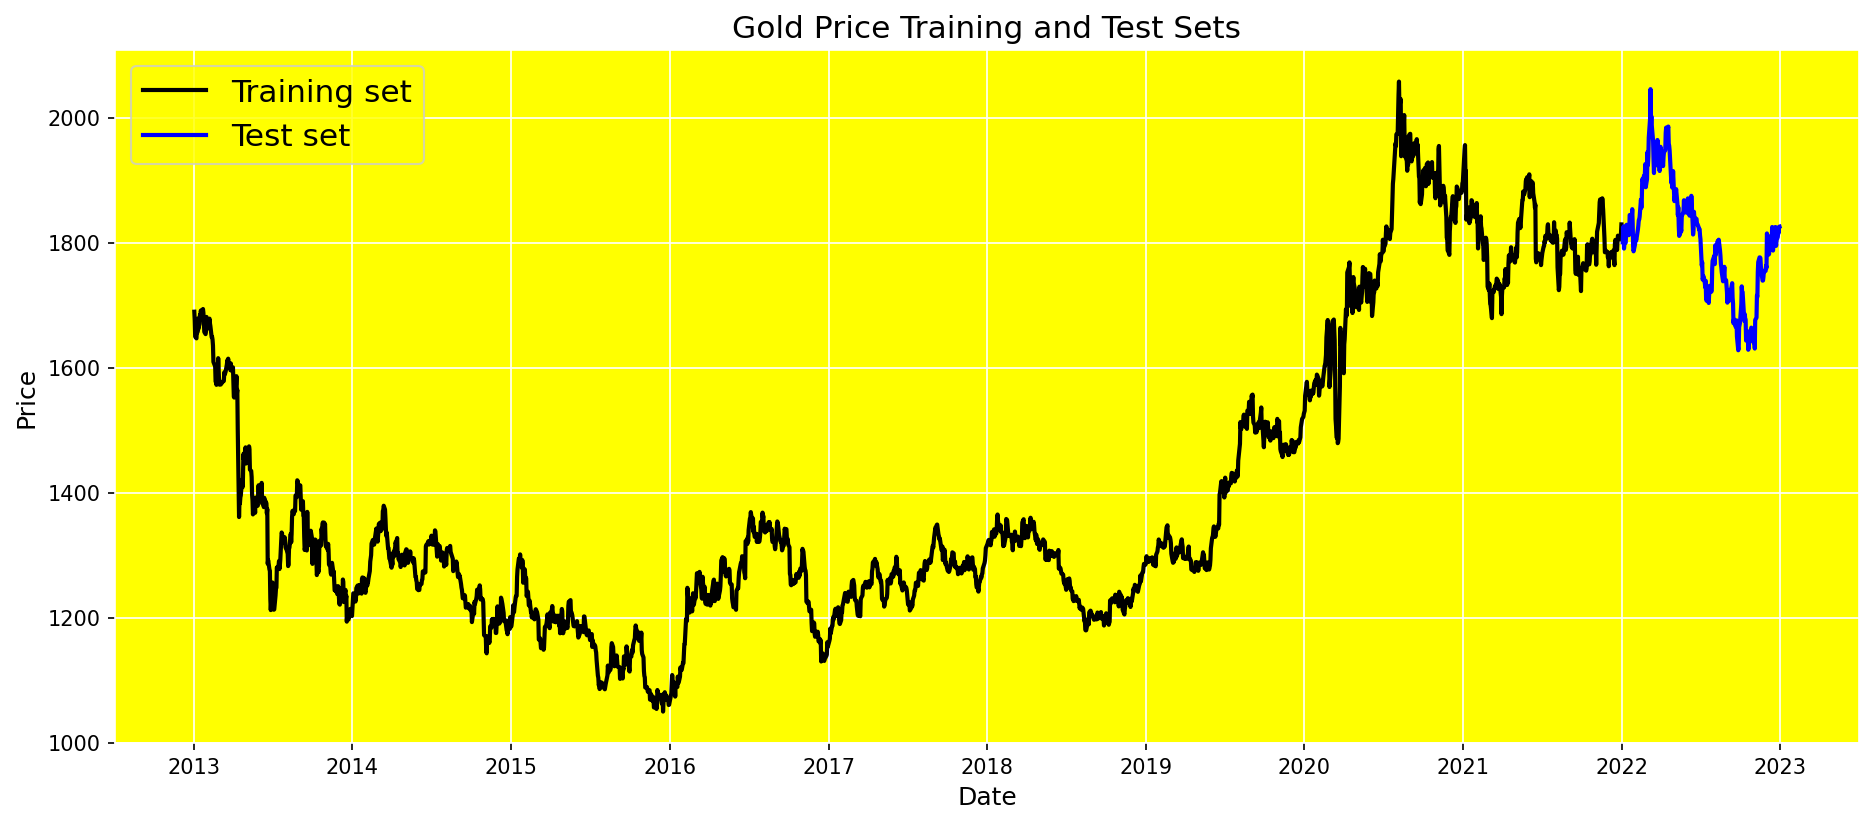

In [ ]:
plt.figure(figsize=(15, 6), dpi=150)
plt.rcParams['axes.facecolor'] = 'yellow'
plt.rc('axes', edgecolor='white')
plt.plot(df.Date[:-test_size], df.Price[:-test_size], color='black', lw=2)
plt.plot(df.Date[-test_size:], df.Price[-test_size:], color='blue', lw=2)
plt.title('Gold Price Training and Test Sets', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(['Training set', 'Test set'], loc='upper left', prop={'size': 15})
plt.grid(color='white')
plt.show()

In [ ]:
scaler = MinMaxScaler()
scaler.fit(df.Price.values.reshape(-1, 1))

MinMaxScaler()

In [ ]:
window_size = 60
train_data = df.Price[:-test_size]
train_data = scaler.transform(train_data.values.reshape(-1, 1))

X_train, y_train = [], []
for i in range(window_size, len(train_data)):
    X_train.append(train_data[i - 60:i, 0])
    y_train.append(train_data[i, 0])

test_data = df.Price[-test_size - 60:]
test_data = scaler.transform(test_data.values.reshape(-1, 1))

X_test, y_test = [], []
for i in range(window_size, len(test_data)):
    X_test.append(test_data[i - 60:i, 0])
    y_test.append(test_data[i, 0])

In [ ]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
y_train = np.reshape(y_train, (-1, 1))
y_test = np.reshape(y_test, (-1, 1))

print('X_train Shape: ', X_train.shape)
print('y_train Shape: ', y_train.shape)
print('X_test Shape:  ', X_test.shape)
print('y_test Shape:  ', y_test.shape)


X_train Shape:  (2263, 60, 1)
y_train Shape:  (2263, 1)
X_test Shape:   (260, 60, 1)
y_test Shape:   (260, 1)


In [ ]:
from tensorflow.keras.layers import Input

def define_model():
    input1 = Input(shape=(window_size, 1))
    x = LSTM(units=35, return_sequences=False)(input1)
    x = Dropout(0.4)(x)
    x = Dense(16, activation='relu')(x)
    dnn_output = Dense(1)(x)

    model = Model(inputs=input1, outputs=dnn_output)
    model.compile(loss='mean_squared_error', optimizer='adam')
    model.summary()

    return model

model = define_model()
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.5,
    verbose=1
)

NameError: name 'window_size' is not defined

In [ ]:
result = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0214
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


In [ ]:
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test_true, y_test_pred)
mse = mean_squared_error(y_test_true, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_true, y_test_pred)
mape = mean_absolute_percentage_error(y_test_true, y_test_pred)
accuracy = 1 - mape

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"MAPE: {mape}")
print(f"R-squared (R²): {r2}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")



9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Mean Squared Error (MSE): 19353.315352646405
Root Mean Squared Error (RMSE): 139.1161937110357
Mean Absolute Error (MAE): 135.65412353515626
MAPE: 0.07464333057220687
R-squared (R²): -1.3347416715176954
Model Accuracy: 92.54%


In [ ]:
y_test_true = scaler.inverse_transform(y_test)
y_test_pred = scaler.inverse_transform(y_pred)

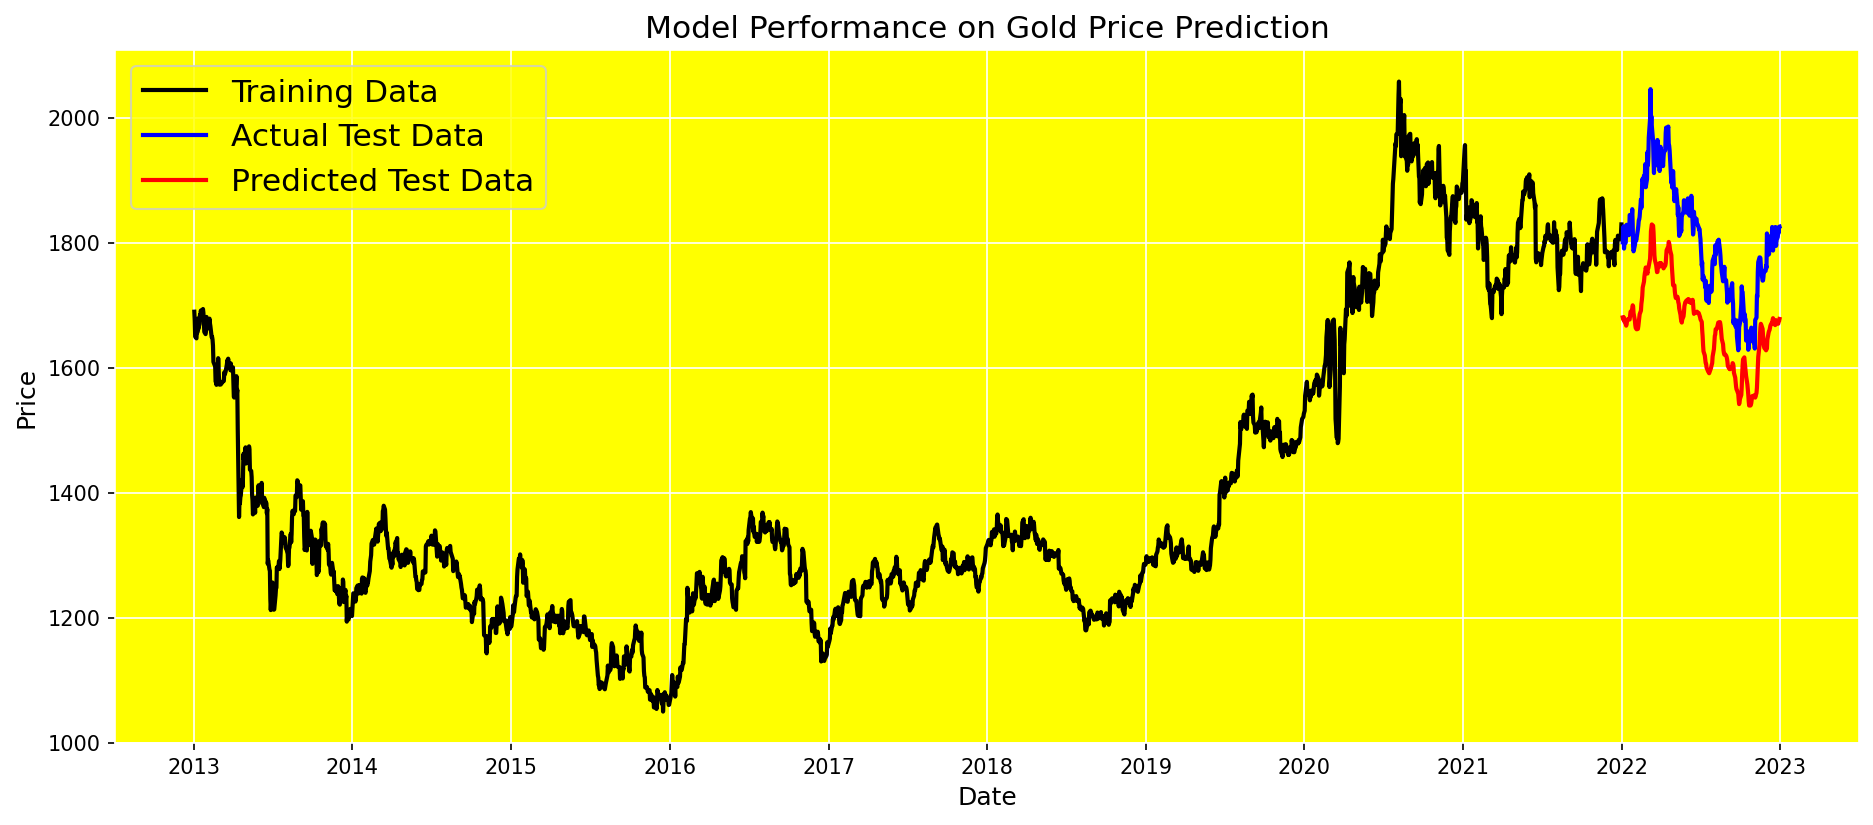

In [ ]:
plt.figure(figsize=(15, 6), dpi=150)
plt.rcParams['axes.facecolor'] = 'yellow'
plt.rc('axes', edgecolor='white')
plt.plot(df['Date'].iloc[:-test_size], scaler.inverse_transform(train_data), color='black', lw=2)
plt.plot(df['Date'].iloc[-test_size:], y_test_true, color='blue', lw=2)
plt.plot(df['Date'].iloc[-test_size:], y_test_pred, color='red', lw=2)
plt.title('Model Performance on Gold Price Prediction', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(['Training Data', 'Actual Test Data', 'Predicted Test Data'], loc='upper left', prop={'size': 15})
plt.grid(color='white')
plt.show()

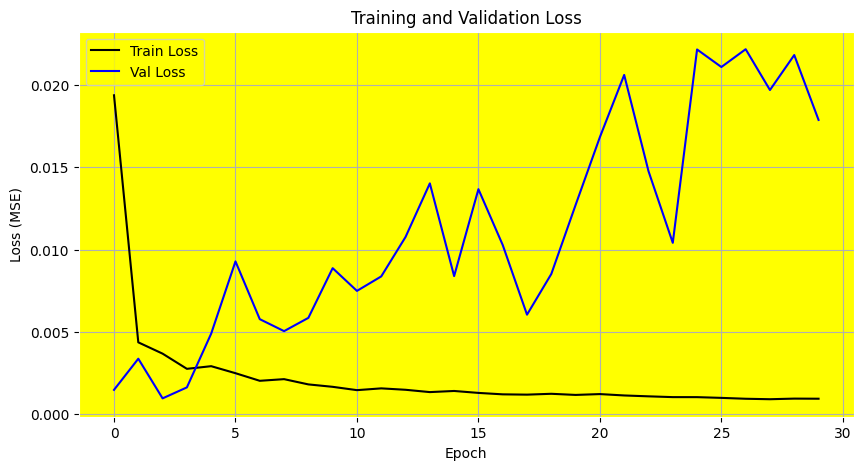

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='black')
plt.plot(history.history['val_loss'], label='Val Loss', color='blue')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()